In [200]:
import pandas as pd
import os
from io import StringIO
from pandas import json_normalize
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import hmean

In [201]:
dataset = "Pubmed"
folder = os.path.join("output","runs","LinkAttack")

files = [f for f in os.listdir(folder) if dataset in f and ('50' not in f) and ('99' not in f)]
files

['Pubmed_SGC_edge.json',
 'Pubmed_GCN_edge.json',
 'Pubmed_SGC_CGU_edge.json',
 'Pubmed_GIN_edge.json',
 'Pubmed_GraphSAGE_edge.json',
 'Pubmed_GAT_edge.json']

In [202]:
column_list = ['unlearner', 'dataset', 'architecture', 'optimizer.parameters.lr','lr',
       'RunTime', 'PeakRSS_MB', 'CudaPeak_MB', 'AUS', 'UMIA',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:True', 'sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.train.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:False',
       'sklearn.metrics.accuracy_score.test.original.on_graph:False',
       'f1_macro.test.unlearned.on_graph:True',
       'f1_macro.test.original.on_graph:True',
       'f1_macro.forget.unlearned.on_graph:True',
       'f1_macro.forget.original.on_graph:True',
       'Link Stealing Attack unlearned 0 exist/non_exist',
       'Link Stealing Attack 0 unlearned forget/non_exist', 'LinkTeller unlearn with sampler bfs+:',
       'LinkTeller original with sampler bfs+:']


In [203]:
total_df = pd.DataFrame()

for file in files:
    architecture = file.split("_")[1]
    if architecture == "SGC" and "CGU" in file:
        architecture = "SGC_CGU"
        
    file = os.path.join(folder,file)
    with open(file, "r") as f:
        text = f.read().strip()

    if not text.startswith("["):
        text = "[" + text
    if text.endswith(","):
        text = text[:-1]
    if not text.endswith("]"):
        text = text + "]"

    df = pd.read_json(StringIO(text))

    df_expanded = json_normalize(df['parameters'])
    df = pd.concat([df.drop(columns='parameters'), df_expanded], axis=1)

    df['architecture'] = architecture

    cols = list(df.columns)

    #cols.insert(2, cols.pop(cols.index('optimizer.parameters.lr')))

    cols.insert(2, cols.pop(cols.index('architecture')))

    df = df[cols]
    
    total_df = pd.concat([total_df,df])

In [204]:
total_df = total_df[column_list]

In [205]:
linkteller_unlearn = total_df["LinkTeller unlearn with sampler bfs+:"].apply(pd.Series)
linkteller_unlearn = linkteller_unlearn.rename(columns=lambda x: f"LinkTeller_unlearn_{x}")

linkteller_original = total_df["LinkTeller original with sampler bfs+:"].apply(pd.Series)
linkteller_original = linkteller_original.rename(columns=lambda x: f"LinkTeller_original_{x}")

total_df = pd.concat([total_df.drop(columns=[
    "LinkTeller unlearn with sampler bfs+:",
    "LinkTeller original with sampler bfs+:"
]), linkteller_unlearn, linkteller_original], axis=1)

total_df.drop(columns=["LinkTeller_unlearn_0", "LinkTeller_original_0"], inplace=True)


In [206]:
total_df

,unlearner,dataset,architecture,optimizer.parameters.lr,lr,RunTime,PeakRSS_MB,CudaPeak_MB,AUS,UMIA,...,f1_macro.test.unlearned.on_graph:True,f1_macro.test.original.on_graph:True,f1_macro.forget.unlearned.on_graph:True,f1_macro.forget.original.on_graph:True,Link Stealing Attack unlearned 0 exist/non_exist,Link Stealing Attack 0 unlearned forget/non_exist,LinkTeller_unlearn_auc,LinkTeller_unlearn_ap,LinkTeller_original_auc,LinkTeller_original_ap
0,Identity,Pubmed,SGC,NaN,NaN,0.000208,2173.285156,566.075684,0.964904,0.504326,...,0.467922,0.467922,0.478704,0.478704,0.575322,0.579543,NaN,NaN,NaN,NaN
1,GoldModelGraph,Pubmed,SGC,NaN,NaN,0.227571,2409.000000,1173.433594,0.965159,0.641832,...,0.441917,0.467922,0.436453,0.478704,0.557241,0.556641,NaN,NaN,NaN,NaN
2,Finetuning,Pubmed,SGC,0.001,NaN,1.062911,2477.660156,1212.585938,0.984278,0.501917,...,0.474540,0.467922,0.485288,0.478704,0.565355,0.569774,NaN,NaN,NaN,NaN
3,SuccessiveRandomLabels,Pubmed,SGC,0.001,NaN,1041.285369,2508.351562,1212.603027,0.956050,0.502361,...,0.468686,0.467922,0.477475,0.478704,0.589553,0.593118,NaN,NaN,NaN,NaN
4,Finetuning,Pubmed,SGC,0.001,NaN,0.884921,2521.691406,1212.597168,0.984278,0.505181,...,0.474540,0.467922,0.485288,0.478704,0.565354,0.569775,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12,SelectiveSynapticDampening,Pubmed,GAT,0.001,0.1,1128.985686,2896.242188,885.871094,0.989908,0.499794,...,0.446686,0.446478,0.456902,0.456460,0.936918,0.937224,0.212148,0.658679,0.212148,0.658679
13,Cascade,Pubmed,GAT,NaN,NaN,1233.397080,2938.175781,886.588867,0.992047,0.502646,...,0.448463,0.446478,0.470277,0.456460,0.936409,0.936549,0.211875,0.658679,0.211712,0.658679
14,IDEA,Pubmed,GAT,NaN,NaN,3.605227,3064.605469,2056.512207,0.993858,0.503724,...,0.446972,0.446478,0.456019,0.456460,0.934432,0.934656,0.220475,0.658679,0.212583,0.658679
15,CGU_edge,Pubmed,GAT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.446478,NaN,0.456460,NaN,NaN,NaN,NaN,0.212529,0.658679


In [207]:
metric_cols = [c for c in df.columns if c not in ["unlearner","dataset","architecture","lr","RunTime"]]

gold_baseline = total_df.loc[total_df.unlearner == 'GoldModelGraph']

for i, row in df.iterrows():
    if row["unlearner"] in ["Identity", "GoldModelGraph"]:
        continue  

    arch = row["architecture"]
    if arch in gold_baseline['architecture']:
        for col in metric_cols:
            df.at[i, col] = row[col] - gold_baseline.loc[arch, col]

In [208]:
df

,unlearner,dataset,architecture,RunTime,PeakRSS_MB,CudaPeak_MB,sklearn.metrics.accuracy_score.test.unlearned.on_graph:True,sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True,sklearn.metrics.accuracy_score.train.unlearned.on_graph:True,sklearn.metrics.accuracy_score.test.unlearned.on_graph:False,...,compare_retrain,delta,eps,train_mode,y_binary,lam,num_steps_optimizer,cg_approx,transductive_edge,damping
0,Identity,Pubmed,GAT,0.000123,2273.421875,581.277344,0.593813,0.608253,0.598338,0.595842,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GoldModelGraph,Pubmed,GAT,0.225087,2542.285156,888.543457,0.584686,0.589674,0.588264,0.584686,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Finetuning,Pubmed,GAT,1.949669,2610.082031,880.221191,0.601420,0.615162,0.606438,0.605477,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SuccessiveRandomLabels,Pubmed,GAT,1132.810816,2666.128906,880.491699,0.599138,0.622631,0.602987,0.598124,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Finetuning,Pubmed,GAT,1.617070,2685.156250,880.611816,0.601927,0.614415,0.604748,0.603955,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,eu_k,Pubmed,GAT,1.391419,2697.292969,881.588379,0.629817,0.649052,0.632784,0.632099,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NegGrad,Pubmed,GAT,1.425366,2720.234375,881.782227,0.583671,0.596490,0.587560,0.584939,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,AdvancedNegGrad,Pubmed,GAT,1113.455598,2720.234375,957.220215,0.600152,0.617029,0.602916,0.602181,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Cascade,Pubmed,GAT,3.067366,2774.007812,1110.030273,0.606491,0.620390,0.612003,0.610548,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,BadTeaching,Pubmed,GAT,1112.205708,2774.007812,923.226562,0.600659,0.621977,0.607284,0.602434,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [209]:
def harmonic_mean(row, metrics):
    values = row[metrics].values
    values = values[values > 0]
    if len(values) == 0:
        return np.nan
    return len(values) / np.sum(1.0 / values)

In [210]:
column_list = ['unlearner', 'dataset', 'architecture', 'optimizer.parameters.lr','lr',
       'RunTime', 'AUS', 'UMIA',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:True', 'sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.train.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:False',
       'sklearn.metrics.accuracy_score.test.original.on_graph:False',
       'Link Stealing Attack unlearned 0 exist/non_exist',
       'Link Stealing Attack 0 unlearned forget/non_exist', 'LinkTeller_unlearn_auc',
       'LinkTeller_unlearn_ap', 'LinkTeller_original_auc', 'LinkTeller_original_ap']

total_df = total_df[column_list]
total_df.reset_index(drop=True, inplace=True)

In [211]:
metric_cols = [c for c in column_list if c not in ["unlearner","dataset","architecture","lr","RunTime", 'optimizer.parameters.lr',  'Link Stealing Attack unlearned 0 exist/non_exist',
 'Link Stealing Attack 0 unlearned forget/non_exist',
 'LinkTeller_unlearn_auc',
 'LinkTeller_unlearn_ap',
 'LinkTeller_original_auc',
 'LinkTeller_original_ap']]

In [212]:
metric_cols

['AUS',
 'UMIA',
 'sklearn.metrics.accuracy_score.test.unlearned.on_graph:True',
 'sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True',
 'sklearn.metrics.accuracy_score.train.unlearned.on_graph:True',
 'sklearn.metrics.accuracy_score.test.unlearned.on_graph:False',
 'sklearn.metrics.accuracy_score.test.original.on_graph:False']

In [213]:
total_df[metric_cols] = total_df[metric_cols].clip(lower=0)

/tmp/ipykernel_3155847/2383361326.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  total_df[metric_cols] = total_df[metric_cols].clip(lower=0)


In [214]:
total_df["harmonic_mean"] = total_df[metric_cols].apply(
    lambda row: hmean(row.dropna()) if row.dropna().size > 0 else np.nan,
    axis=1
)

/tmp/ipykernel_3155847/2817058301.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  total_df["harmonic_mean"] = total_df[metric_cols].apply(


In [215]:
total_df

,unlearner,dataset,architecture,optimizer.parameters.lr,lr,RunTime,AUS,UMIA,sklearn.metrics.accuracy_score.test.unlearned.on_graph:True,sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True,sklearn.metrics.accuracy_score.train.unlearned.on_graph:True,sklearn.metrics.accuracy_score.test.unlearned.on_graph:False,sklearn.metrics.accuracy_score.test.original.on_graph:False,Link Stealing Attack unlearned 0 exist/non_exist,Link Stealing Attack 0 unlearned forget/non_exist,LinkTeller_unlearn_auc,LinkTeller_unlearn_ap,LinkTeller_original_auc,LinkTeller_original_ap,harmonic_mean
0,Identity,Pubmed,SGC,NaN,NaN,0.000208,0.964904,0.504326,0.524594,0.540752,0.526345,0.533976,0.533976,0.575322,0.579543,NaN,NaN,NaN,NaN,0.563602
1,GoldModelGraph,Pubmed,SGC,NaN,NaN,0.227571,0.965159,0.641832,0.491633,0.488096,0.489645,0.491633,0.533976,0.557241,0.556641,NaN,NaN,NaN,NaN,0.554410
2,Finetuning,Pubmed,SGC,0.001,NaN,1.062911,0.984278,0.501917,0.533976,0.550649,0.537264,0.549189,0.533976,0.565355,0.569774,NaN,NaN,NaN,NaN,0.571335
3,SuccessiveRandomLabels,Pubmed,SGC,0.001,NaN,1041.285369,0.956050,0.502361,0.516988,0.531416,0.518949,0.525862,0.533976,0.589553,0.593118,NaN,NaN,NaN,NaN,0.557592
4,Finetuning,Pubmed,SGC,0.001,NaN,0.884921,0.984278,0.505181,0.533976,0.550649,0.537264,0.549189,0.533976,0.565354,0.569775,NaN,NaN,NaN,NaN,0.571936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,SelectiveSynapticDampening,Pubmed,GAT,0.001,0.1,1128.985686,0.989908,0.499794,0.594067,0.608533,0.598690,0.595081,0.595842,0.936918,0.937224,0.212148,0.658679,0.212148,0.658679,0.615835
98,Cascade,Pubmed,GAT,NaN,NaN,1233.397080,0.992047,0.502646,0.595081,0.613295,0.600169,0.597110,0.595842,0.936409,0.936549,0.211875,0.658679,0.211712,0.658679,0.617954
99,IDEA,Pubmed,GAT,NaN,NaN,3.605227,0.993858,0.503724,0.598124,0.613388,0.602705,0.598124,0.595842,0.934432,0.934656,0.220475,0.658679,0.212583,0.658679,0.619307
100,CGU_edge,Pubmed,GAT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.595842,NaN,NaN,NaN,NaN,0.212529,0.658679,0.595842


In [216]:
total_df['architecture'].unique()

array(['SGC', 'GCN', 'SGC_CGU', 'GIN', 'GraphSAGE', 'GAT'], dtype=object)

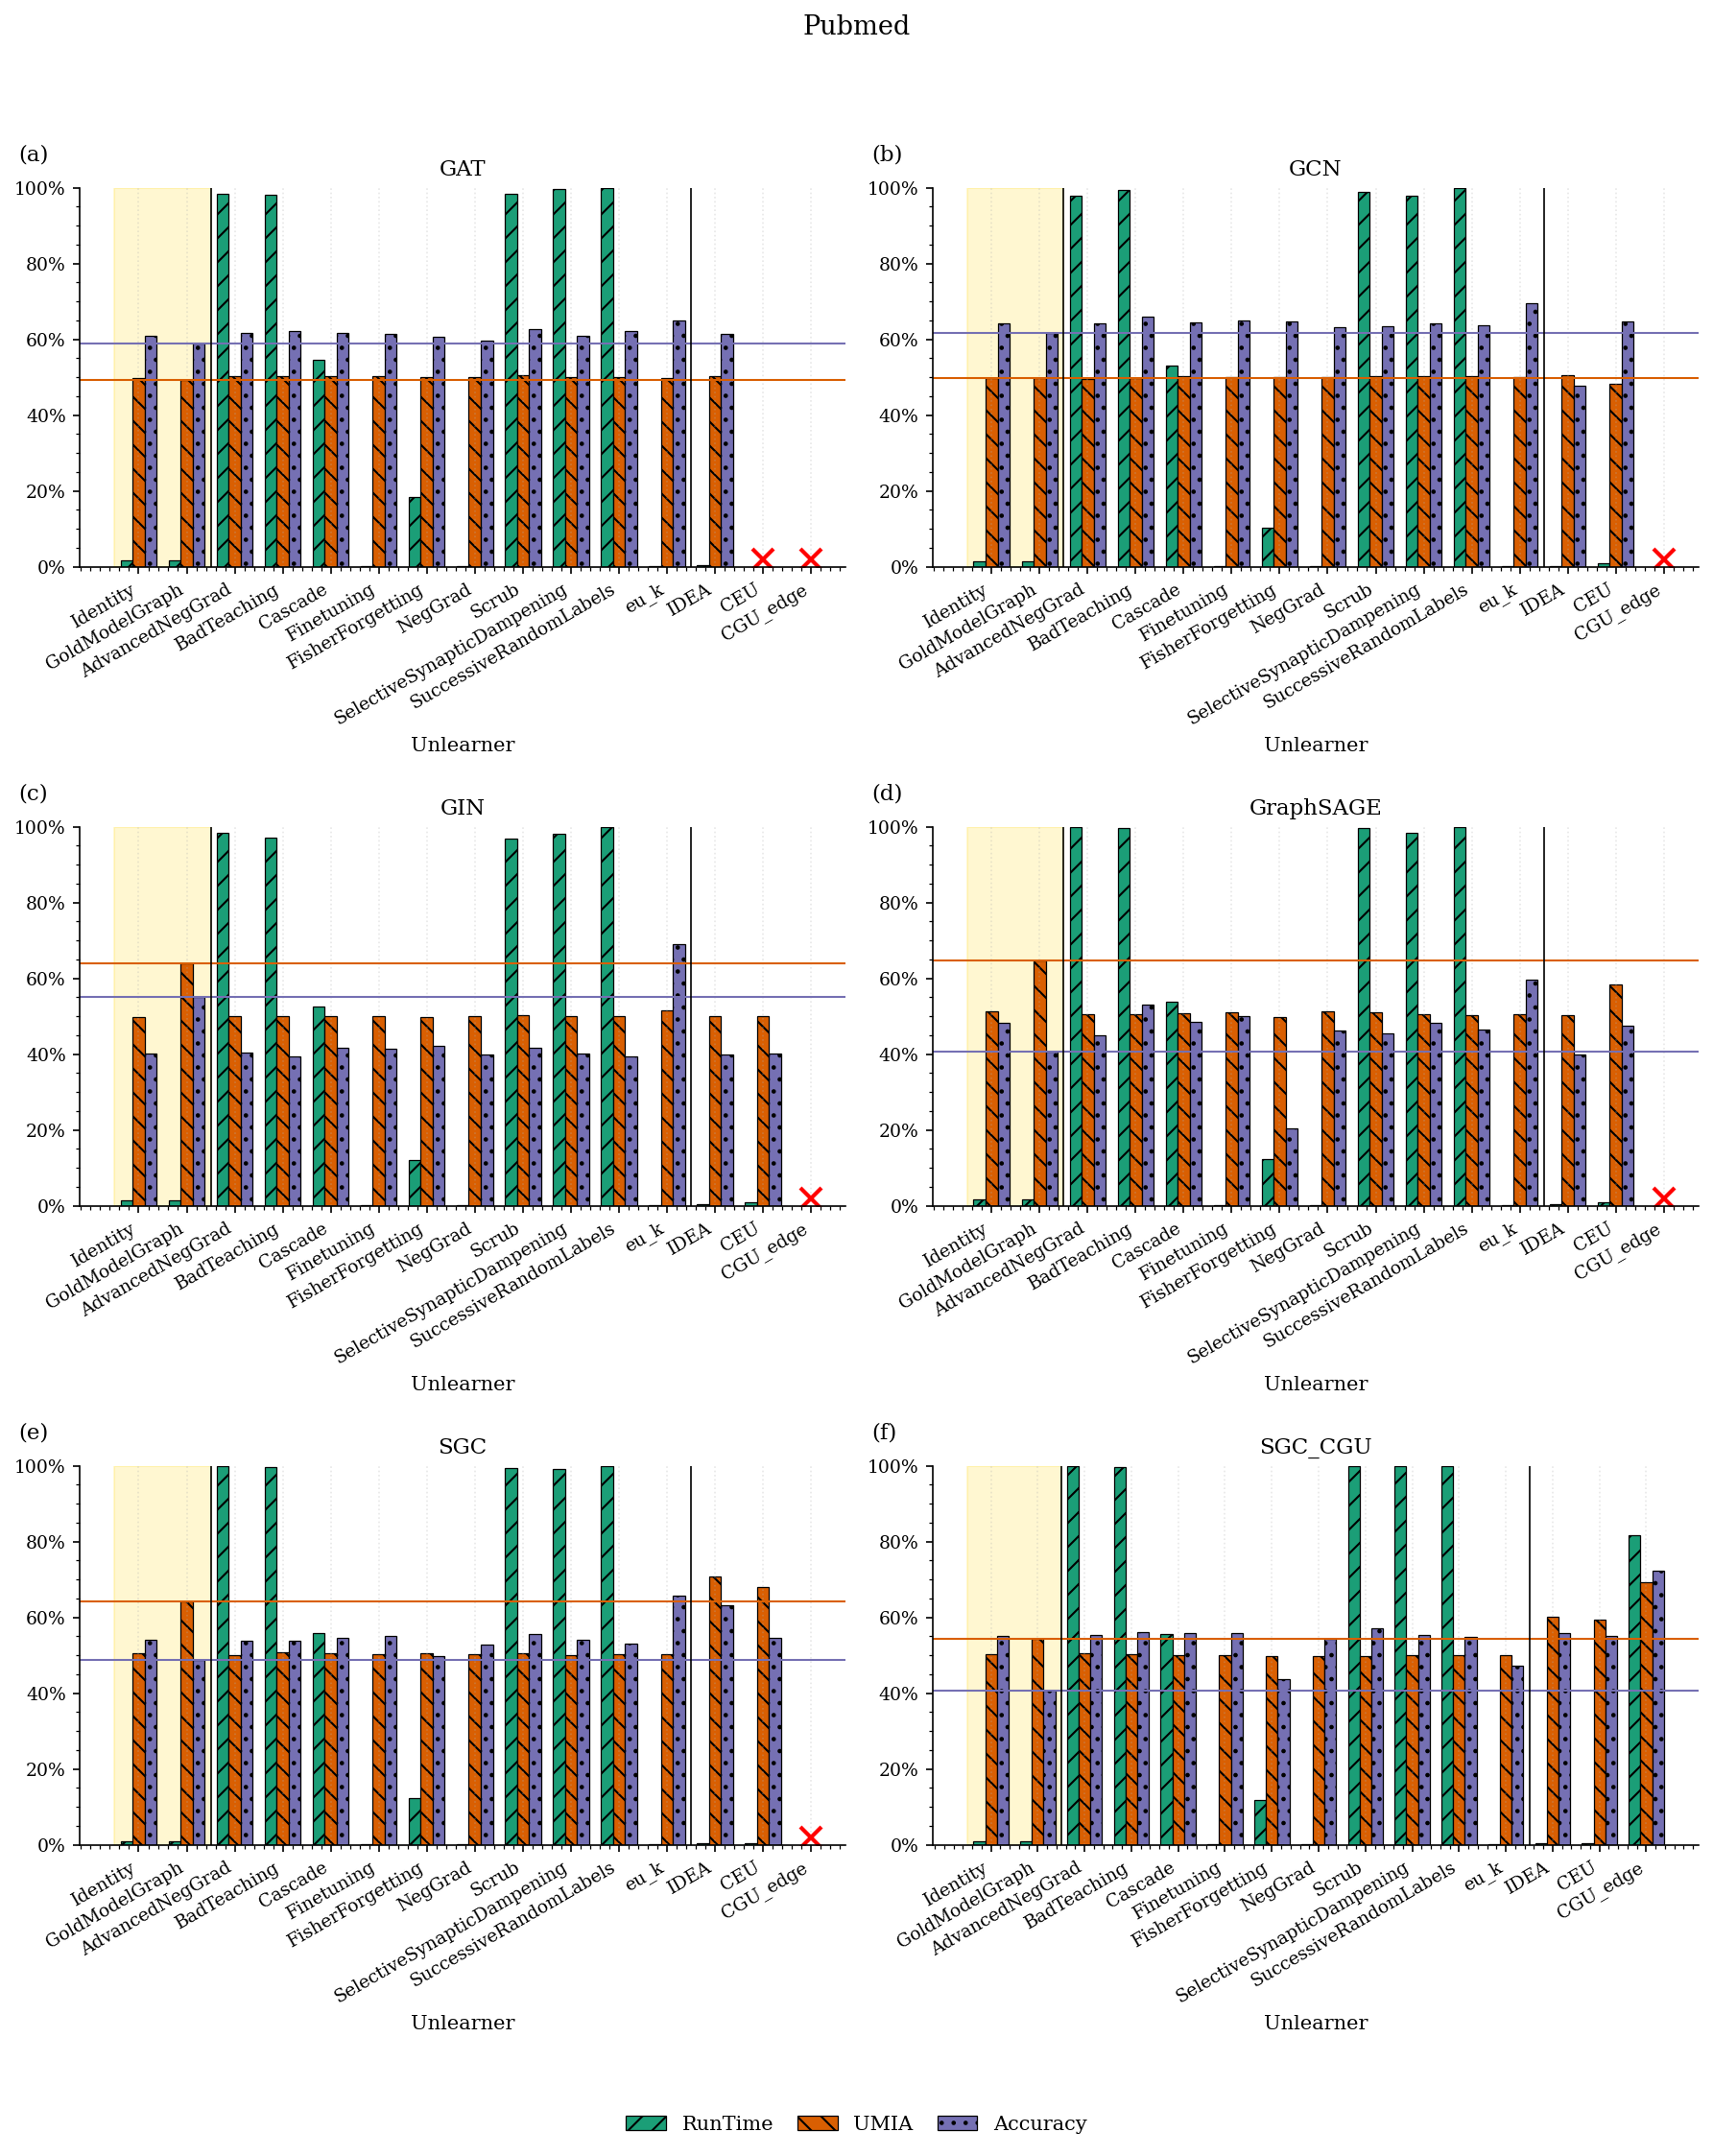

In [217]:
# --- Style polish: researchy vibe, no functional changes ---
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from string import ascii_lowercase

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})

ACC_COL = "sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True"
METRICS = ["RunTime", "UMIA", ACC_COL]
DISPLAY_NAME = {
    "RunTime": "RunTime",
    "UMIA": "UMIA",
    ACC_COL: "Accuracy",
}

COLOR = {
    "RunTime": "#1b9e77",   # deep green-teal
    "UMIA":    "#d95f02",   # muted orange
    ACC_COL:   "#7570b3",   # indigo/purple
}
# b/w & color-blind friendly hatches per metric
HATCH = {
    "RunTime": "//",
    "UMIA":    "\\\\",
    ACC_COL:   "..",
}

HEAD = ["Identity", "GoldModelGraph"]        # shaded in gold
TAIL = ["IDEA", "CEU", "CGU_edge"]           # moved to the end

architectures = sorted(total_df["architecture"].unique())
n_arch = len(architectures)

# choose grid size (e.g. square-ish)
ncols = 2  # or 3 if you have many
nrows = math.ceil(n_arch / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), squeeze=False)

for idx, arch in enumerate(architectures):
    ax = axes[idx // ncols, idx % ncols]  # pick correct subplot

    sub = total_df[total_df["architecture"] == arch].copy()
    agg = sub.groupby("unlearner")[METRICS].mean()

    # scale Identity / GoldModel runtime (as in your code)
    if "Finetuning" in agg.index:
        base = agg.loc["Finetuning", "RunTime"]
        if base > 0:
            for special in ["Identity", "GoldModelGraph"]:
                if special in agg.index:
                    agg.loc[special, "RunTime"] = base * 10

    # normalize runtime (as in your code)
    if agg["RunTime"].notna().any():
        max_rt = agg["RunTime"].max()
        if max_rt > 0:
            agg["RunTime"] /= max_rt

    # ordering (unchanged)
    present = list(agg.index)
    head_present = [u for u in HEAD if u in present]
    tail_present = [u for u in TAIL if u in present]
    middle = sorted([u for u in present if u not in head_present + tail_present])
    ordered_unlearners = head_present + middle + tail_present
    agg = agg.reindex(ordered_unlearners)

    x = np.arange(len(ordered_unlearners))
    width = 0.25
    offsets = np.linspace(-width, width, len(METRICS))

    # axes cosmetics
    ax.set_title(arch)
    ax.set_xlabel("Unlearner")
    if idx // ncols == 0:
        ax.set_ylim(0, 1)  # all three metrics are in [0,1] after your normalization
    else:
        ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.minorticks_on()
    ax.grid(axis="x", linestyle=":", alpha=0.3)   # vertical only, subtle
    ax.tick_params(axis="x", rotation=30)

    # gold shading for HEAD
    if head_present:
        ax.axvspan(-0.5, len(head_present) - 0.5, color="#FFD700", alpha=0.18, zorder=0)

    # UMIA validity mask (unchanged)
    umia = agg["UMIA"].values if "UMIA" in agg.columns else np.full(len(x), np.nan)
    valid_mask = ~(np.isnan(umia) | (umia == 0))

    # red X for invalid groups (same logic, styled)
    if (~valid_mask).any():
        ymin, ymax = ax.get_ylim()
        offset = 0.02 * (ymax - ymin) if ymax > ymin else 0.02
        ax.plot(
            x[~valid_mask],
            np.full((~valid_mask).sum(), offset),
            marker="x", linestyle="None", color="red",
            markersize=11, markeredgewidth=2
        )

    # bars for valid groups (same functionality, with edge + hatch)
    for i, metric in enumerate(METRICS):
        vals = agg[metric].values
        ax.bar(
            x[valid_mask] + offsets[i],
            vals[valid_mask],
            width,
            label=DISPLAY_NAME[metric],
            color=COLOR[metric],
            edgecolor="black",
            linewidth=0.6,
            hatch=HATCH[metric],
        )

    ax.set_xticks(x)
    ax.set_xticklabels(ordered_unlearners, ha="right", fontsize=9)

    # reference lines from GoldModel (unchanged, slightly thinner)
    if "GoldModelGraph" in agg.index:
        gold = agg.loc["GoldModelGraph"]
        if np.isfinite(gold["UMIA"]):
            ax.axhline(y=gold["UMIA"], color=COLOR["UMIA"], linestyle="-", linewidth=1.0)
        if np.isfinite(gold[ACC_COL]):
            ax.axhline(y=gold[ACC_COL], color=COLOR[ACC_COL], linestyle="-", linewidth=1.0)

    # vertical separators (unchanged)
    if head_present and len(head_present) < len(ordered_unlearners):
        ax.axvline(x=len(head_present)-0.5, color="black", linestyle="-", linewidth=0.8)
    if tail_present:
        idx_before_tail = len(head_present) + len(middle) - 0.5
        if -0.5 <= idx_before_tail < len(ordered_unlearners)-0.5:
            ax.axvline(x=idx_before_tail, color="black", linestyle="-", linewidth=0.8)

    # panel label (a), (b), ...
    ax.text(-0.08, 1.06, f"({ascii_lowercase[idx]})", transform=ax.transAxes,
            va="bottom", ha="left", fontsize=11)

# clean up empty subplots if any (unchanged)
for j in range(idx+1, nrows*ncols):
    fig.delaxes(axes[j // ncols, j % ncols])

# super title + tight layout
fig.suptitle(f"{dataset}", fontsize=13, y=0.995)
fig.tight_layout(rect=[0, 0.05, 1, 0.97])  # leave a bit more bottom room

# single legend below (tidy, with hatches)
legend_handles = [plt.Rectangle((0,0), 1, 1, facecolor=COLOR[m],
                                edgecolor="black", linewidth=0.6, hatch=HATCH[m])
                  for m in METRICS]
legend_labels = [DISPLAY_NAME[m] for m in METRICS]
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc="lower center",
    ncol=len(METRICS),
    frameon=False,
    bbox_to_anchor=(0.5, 0.005),
    handlelength=2.0,
    columnspacing=1.2,
)

# export (PNG/PDF); transparent = nice for papers
outdir = "figures"
os.makedirs(outdir, exist_ok=True)

plt.savefig(os.path.join(outdir, f"{dataset}_plots_forget.pdf"),
            bbox_inches="tight", transparent=True)
plt.show()
